<div style="background-color:#ED1C24; color:white; padding:20px 30px; border-radius:10px;">
<h1 style="color:white; margin:0;">Session 6.1: Vectors, Matrices & Linear Algebra</h1>
<p style="color:white; margin:5px 0 0 0;">Practical Lab — Hands-on Linear Algebra with NumPy</p>
</div>

## Learning Objectives

By the end of this lab, you will be able to:

1. Create vectors as NumPy arrays and compute dot products and magnitudes
2. Create matrices using `np.array()`, `np.zeros()`, `np.ones()`, `np.eye()`
3. Perform matrix multiplication using `@` with dimension compatibility rules
4. Compute matrix transpose using `.T`
5. Represent and manipulate digital images as 3D NumPy arrays
6. Use `np.linalg` functions for norm, determinant, inverse, and solving linear systems
7. Compute cosine similarity between vectors for recommendation systems

## Business Context: The Netflix Prize

In 2006, Netflix offered **$1 million** to anyone who could improve their movie recommendation algorithm by 10%. Over 40,000 teams from 186 countries entered. The winning insight: represent every user and every movie as a **vector**, then measure similarity using **dot products** and **cosine similarity**. Today, we learn the exact mathematical foundations that powered this solution — and build our own mini recommendation engine.

## Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print(f"NumPy version: {np.__version__}")
print("Setup complete!")

NumPy version: 2.4.6
Setup complete!


<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 1: Vectors — The Language of Data</h2>
</div>

A **vector** is a 1D NumPy array that represents a single data point. In machine learning, every observation — a customer, a product, an image — is represented as a vector.

Let's create vectors representing movie ratings for three users:

In [4]:
# Movies: [Inception, Titanic, Avengers, Notebook, Interstellar]
# Ratings: 1-5 scale

user_alice = np.array([5, 2, 5, 1, 4])  # Loves action/sci-fi
user_bob   = np.array([4, 1, 4, 2, 5])  # Similar to Alice
user_carol = np.array([1, 5, 2, 5, 1])  # Loves romance

print("Alice's ratings:", user_alice)
print("Bob's ratings:  ", user_bob)
print("Carol's ratings:", user_carol)
print(f"\nEach vector has {len(user_alice)} dimensions (one per movie)")
print(f"Shape: {user_alice.shape}")

Alice's ratings: [5 2 5 1 4]
Bob's ratings:   [4 1 4 2 5]
Carol's ratings: [1 5 2 5 1]

Each vector has 5 dimensions (one per movie)
Shape: (5,)


### The Dot Product — The Fundamental Operation of ML

The **dot product** multiplies corresponding elements and sums the results into a **single number**. It measures how "aligned" two vectors are.

<div style="background: #EBF5FB; color: gray; border-left: 5px solid #3498DB; padding: 15px; margin: 15px 0;">
<strong>Key Concept:</strong> The dot product takes two vectors and produces ONE number. High value = similar preferences. Low value = different preferences.
</div>

In [5]:
# Manual dot product computation
print("=== Manual Dot Product: Alice · Bob ===")
for i in range(5):
    print(f"  {user_alice[i]} × {user_bob[i]} = {user_alice[i] * user_bob[i]}")
manual_result = sum(user_alice[i] * user_bob[i] for i in range(5))
print(f"  Sum = {manual_result}")

print()

# NumPy dot product: two equivalent methods
dot_ab = np.dot(user_alice, user_bob)   # Method 1
dot_ab_at = user_alice @ user_bob        # Method 2

print(f"np.dot(alice, bob) = {dot_ab}")
print(f"alice @ bob        = {dot_ab_at}")

print()

# Compare similarities
dot_ac = user_alice @ user_carol
print(f"Alice · Bob   = {dot_ab}  ← Similar taste (both like action)")
print(f"Alice · Carol = {dot_ac}  ← Different taste (opposite preferences)")

=== Manual Dot Product: Alice · Bob ===
  5 × 4 = 20
  2 × 1 = 2
  5 × 4 = 20
  1 × 2 = 2
  4 × 5 = 20
  Sum = 64

np.dot(alice, bob) = 64
alice @ bob        = 64

Alice · Bob   = 64  ← Similar taste (both like action)
Alice · Carol = 34  ← Different taste (opposite preferences)


In [6]:
np.dot(user_carol, user_bob)

np.int64(32)

### Vector Magnitude (Norm)

The **magnitude** of a vector is its "length" — computed using the Pythagorean theorem in n dimensions:

$$\|v\| = \sqrt{v_0^2 + v_1^2 + \ldots + v_n^2}$$

In [7]:
# Classic example: 3-4-5 triangle
v = np.array([3, 4])
print(f"Vector: {v}")
print(f"Manual: √(3² + 4²) = √(9 + 16) = √25 = {np.sqrt(25)}")
print(f"np.linalg.norm: {np.linalg.norm(v)}")
print()

# User magnitudes
print(f"||Alice|| = {np.linalg.norm(user_alice):.2f}")
print(f"||Bob||   = {np.linalg.norm(user_bob):.2f}")
print(f"||Carol|| = {np.linalg.norm(user_carol):.2f}")
print()

# Magnitude measures SCALE, not PATTERN
generous = np.array([5, 5, 5, 5, 5])
moderate = np.array([3, 3, 3, 3, 3])
print(f"Generous rater [5,5,5,5,5]: magnitude = {np.linalg.norm(generous):.2f}")
print(f"Moderate rater [3,3,3,3,3]: magnitude = {np.linalg.norm(moderate):.2f}")
print("→ Same preferences, different scales. We'll fix this with cosine similarity!")

Vector: [3 4]
Manual: √(3² + 4²) = √(9 + 16) = √25 = 5.0
np.linalg.norm: 5.0

||Alice|| = 8.43
||Bob||   = 7.87
||Carol|| = 7.48

Generous rater [5,5,5,5,5]: magnitude = 11.18
Moderate rater [3,3,3,3,3]: magnitude = 6.71
→ Same preferences, different scales. We'll fix this with cosine similarity!


<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 2: Matrices — Collections of Vectors</h2>
</div>

A **matrix** is a 2D NumPy array that organizes multiple vectors into rows and columns. In ML, rows = samples and columns = features.

In [8]:
# User-Movie Rating Matrix: 6 users × 5 movies
ratings = np.array([
    [5, 2, 5, 1, 4],   # Alice: loves action/sci-fi
    [4, 1, 4, 2, 5],   # Bob: similar to Alice
    [1, 5, 2, 5, 1],   # Carol: loves romance
    [2, 4, 1, 4, 2],   # Dave: similar to Carol
    [5, 3, 4, 2, 5],   # Eve: mixed, leans action
    [3, 5, 3, 4, 2],   # Frank: mixed, leans romance
])

users = ['Alice', 'Bob', 'Carol', 'Dave', 'Eve', 'Frank']
movies = ['Inception', 'Titanic', 'Avengers', 'Notebook', 'Interstellar']

print("User-Movie Rating Matrix:")
print(ratings)
print(f"\nShape: {ratings.shape} → {ratings.shape[0]} users × {ratings.shape[1]} movies")

User-Movie Rating Matrix:
[[5 2 5 1 4]
 [4 1 4 2 5]
 [1 5 2 5 1]
 [2 4 1 4 2]
 [5 3 4 2 5]
 [3 5 3 4 2]]

Shape: (6, 5) → 6 users × 5 movies


### Matrix Indexing

In [9]:
# Single element
print(f"Alice's Inception rating: {ratings[0, 0]}")
print(f"Carol's Notebook rating:  {ratings[2, 3]}")
print()

# Full row = user vector
print(f"Alice's full ratings: {ratings[0, :]}")
print()

# Full column = movie vector
print(f"All Inception ratings: {ratings[:, 0]}")
print(f"Average Inception rating: {ratings[:, 0].mean():.1f}")

Alice's Inception rating: 5
Carol's Notebook rating:  5

Alice's full ratings: [5 2 5 1 4]

All Inception ratings: [5 4 1 2 5 3]
Average Inception rating: 3.3


### Special Matrices

In [10]:
# Identity matrix — the "multiply by 1" of matrices
I = np.eye(3)
print("Identity matrix (3×3):")
print(I)
print()

# Key property: A @ I = A
A = np.array([[1, 2], [3, 4]])
I2 = np.eye(2)
print(f"A @ I = A? {np.array_equal(A, (A @ I2).astype(int))}")

Identity matrix (3×3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

A @ I = A? True


<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 3: Matrix Operations</h2>
</div>

<div style="background: #FEF9E7; color: gray; border-left: 5px solid #F39C12; padding: 15px; margin: 15px 0;">
<strong>⚠️ Critical Distinction:</strong> <code>*</code> (element-wise multiplication) is NOT the same as <code>@</code> (matrix multiplication). Confusing these is the #1 source of bugs in NumPy linear algebra code.
</div>

In [11]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

# Element-wise: multiply corresponding elements
print("A * B (element-wise):")
print(A * B)
print("→ 1×5=5, 2×6=12, 3×7=21, 4×8=32")
print()

# Matrix multiplication: dot products of rows × columns
print("A @ B (matrix multiply):")
print(A @ B)
print("→ [0,0] = 1×5+2×7=19, [0,1] = 1×6+2×8=22")
print("→ [1,0] = 3×5+4×7=43, [1,1] = 3×6+4×8=50")
print()
print("THESE ARE COMPLETELY DIFFERENT RESULTS!")

A * B (element-wise):
[[ 5 12]
 [21 32]]
→ 1×5=5, 2×6=12, 3×7=21, 4×8=32

A @ B (matrix multiply):
[[19 22]
 [43 50]]
→ [0,0] = 1×5+2×7=19, [0,1] = 1×6+2×8=22
→ [1,0] = 3×5+4×7=43, [1,1] = 3×6+4×8=50

THESE ARE COMPLETELY DIFFERENT RESULTS!


### Dimension Compatibility Rule

For `A @ B` to work: **(m×n) @ (n×p) → (m×p)**. The inner dimensions must match.

In [12]:
# Valid: (2,3) @ (3,2) → (2,2)
A = np.array([[1, 2, 3], [4, 5, 6]])   # (2, 3)
B = np.array([[7, 8], [9, 10], [11, 12]])  # (3, 2)
C = A @ B
print(f"{A.shape} @ {B.shape} = {C.shape}")
print(C)
print()

# Invalid: dimensions don't match
D = np.array([[1, 2], [3, 4]])  # (2, 2)
try:
    result = A @ D  # (2,3) @ (2,2) → ERROR!
except ValueError as e:
    print(f"ERROR: {e}")
    print("→ Inner dimensions 3 ≠ 2")

(2, 3) @ (3, 2) = (2, 2)
[[ 58  64]
 [139 154]]

ERROR: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)
→ Inner dimensions 3 ≠ 2


In [13]:
A = np.array([[1, 2, 3], [4, 5, 6]])   # (2, 3)
B = np.array([[7, 8], [9, 10], [11, 12]])  # (3, 2)
print(A)

[[1 2 3]
 [4 5 6]]


In [14]:
print(B)

[[ 7  8]
 [ 9 10]
 [11 12]]


In [15]:
A @ B

array([[ 58,  64],
       [139, 154]])

In [16]:
np.matmul(A,B)

array([[ 58,  64],
       [139, 154]])

### Matrix Transpose

In [17]:
# Transpose swaps rows and columns
print(f"Ratings shape: {ratings.shape} (users × movies)")
print(f"Transposed:    {ratings.T.shape} (movies × users)")
print()

# Now each row is a MOVIE vector
print("Movie vectors (from transposed matrix):")
for i, movie in enumerate(movies):
    print(f"  {movie:>14s}: {ratings.T[i]}")

Ratings shape: (6, 5) (users × movies)
Transposed:    (5, 6) (movies × users)

Movie vectors (from transposed matrix):
       Inception: [5 4 1 2 5 3]
         Titanic: [2 1 5 4 3 5]
        Avengers: [5 4 2 1 4 3]
        Notebook: [1 2 5 4 2 4]
    Interstellar: [4 5 1 2 5 2]


<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 4: Images as 3D Matrices</h2>
</div>

Every digital image is a NumPy array:
- **Grayscale:** 2D array `(height, width)`
- **Color (RGB):** 3D array `(height, width, 3)`

In [21]:
# Create a gradient image from scratch
height, width = 100, 150
image = np.zeros((height, width, 3), dtype=np.uint8)

# Red increases left to right
print(image[:, :, 0].shape)
print(image[:, :, 1].shape)
print(image[:, :, 2].shape)
print(np.linspace(0, 255, width, dtype=np.uint8).shape)
print(np.linspace(0, 255, height, dtype=np.uint8).reshape(-1, 1).shape)
image[:, :, 0] = np.linspace(0, 255, width, dtype=np.uint8)
# Green increases top to bottom
image[:, :, 1] = np.linspace(0, 255, height, dtype=np.uint8).reshape(-1, 1)
# Blue constant
image[:, :, 2] = 100

print(f"Image shape: {image.shape}")
print(f"  Height: {image.shape[0]} pixels")
print(f"  Width:  {image.shape[1]} pixels")
print(f"  Channels: {image.shape[2]} (R, G, B)")
print(f"  Total numbers: {image.size:,}")

(100, 150)
(100, 150)
(100, 150)
(150,)
(100, 1)
Image shape: (100, 150, 3)
  Height: 100 pixels
  Width:  150 pixels
  Channels: 3 (R, G, B)
  Total numbers: 45,000


### Image Operations with NumPy

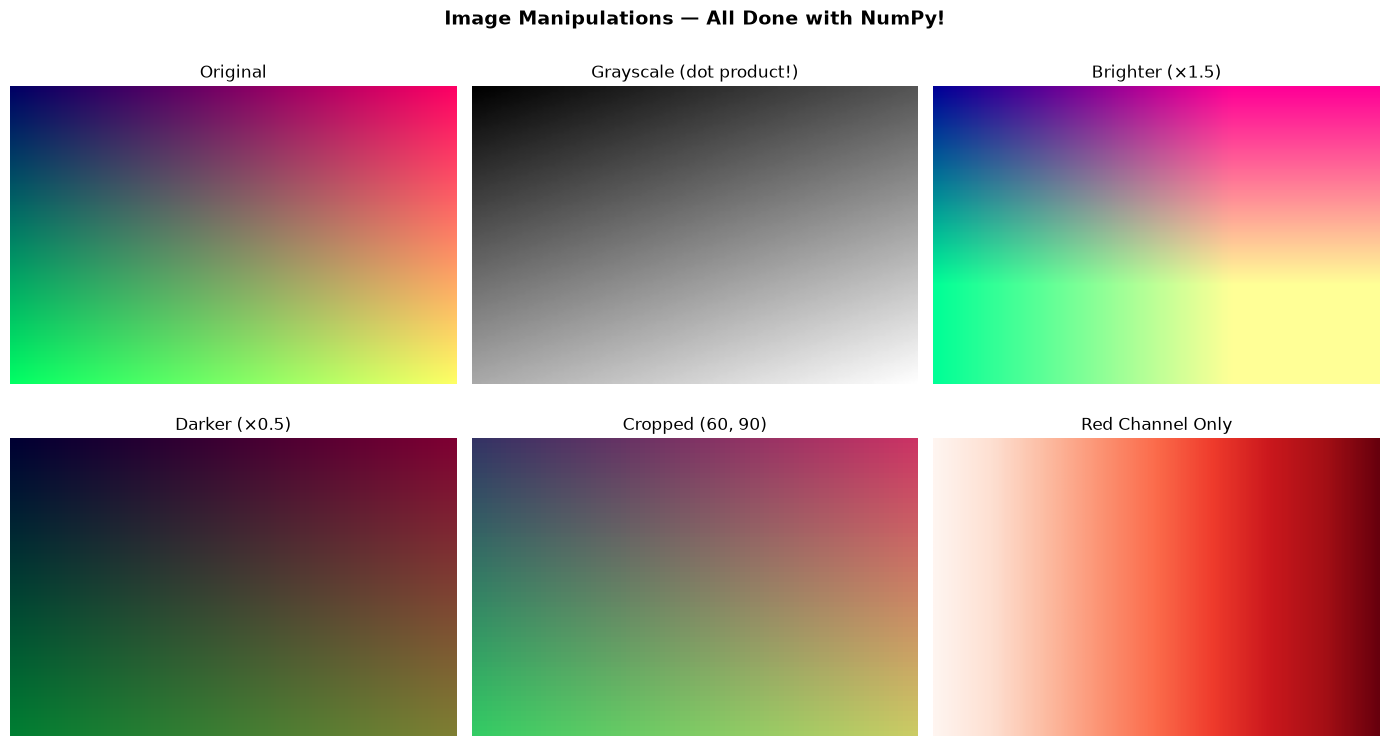

Grayscale = dot product with [0.299, 0.587, 0.114]
Brightness = scalar multiplication
Cropping = array slicing
Channel extraction = 3rd dimension indexing


In [23]:
# Grayscale: dot product with human perception weights
weights = np.array([0.299, 0.587, 0.114])
grayscale = np.dot(image.astype(float), weights).astype(np.uint8)

# Brightness adjustment: scalar multiplication
brighter = np.clip(image.astype(int) * 1.5, 0, 255).astype(np.uint8)
darker = (image * 0.5).astype(np.uint8)

# Cropping: array slicing
cropped = image[20:80, 30:120]

# Display all transformations
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(image)
axes[0, 0].set_title("Original")

axes[0, 1].imshow(grayscale, cmap='gray')
axes[0, 1].set_title("Grayscale (dot product!)")

axes[0, 2].imshow(brighter)
axes[0, 2].set_title("Brighter (×1.5)")

axes[1, 0].imshow(darker)
axes[1, 0].set_title("Darker (×0.5)")

axes[1, 1].imshow(cropped)
axes[1, 1].set_title(f"Cropped {cropped.shape[:2]}")

axes[1, 2].imshow(image[:, :, 0], cmap='Reds')
axes[1, 2].set_title("Red Channel Only")

for ax in axes.flat:
    ax.axis('off')

plt.suptitle("Image Manipulations — All Done with NumPy!", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Grayscale = dot product with [0.299, 0.587, 0.114]")
print("Brightness = scalar multiplication")
print("Cropping = array slicing")
print("Channel extraction = 3rd dimension indexing")

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 5: NumPy Linear Algebra — np.linalg</h2>
</div>

In [24]:
# Determinant: is the matrix invertible?
A = np.array([[2, 1], [5, 3]])
print(f"det(A) = {np.linalg.det(A):.1f} → invertible")

S = np.array([[1, 2], [2, 4]])  # Row 2 = 2 × Row 1
print(f"det(S) = {np.linalg.det(S):.1f} → singular (NOT invertible)")
print()

# Inverse
A_inv = np.linalg.inv(A)
print(f"A inverse:\n{A_inv}")
print(f"A @ A_inv = identity? {np.allclose(A @ A_inv, np.eye(2))}")
print()

# Solve Ax = b
# 2x + y = 5
# 5x + 3y = 13
b = np.array([5, 13])
x = np.linalg.solve(A, b)
print("Solving: 2x + y = 5, 5x + 3y = 13")
print(f"Solution: x = {x[0]:.1f}, y = {x[1]:.1f}")
print(f"Verify: A @ x = {A @ x} (should be {b})")

det(A) = 1.0 → invertible
det(S) = 0.0 → singular (NOT invertible)

A inverse:
[[ 3. -1.]
 [-5.  2.]]
A @ A_inv = identity? True

Solving: 2x + y = 5, 5x + 3y = 13
Solution: x = 2.0, y = 1.0
Verify: A @ x = [ 5. 13.] (should be [ 5 13])


<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 6: Cosine Similarity</h2>
</div>

The dot product is biased by magnitude — a generous rater has high dot products with everyone. **Cosine similarity** fixes this by normalizing:

$$\text{cosine\_similarity}(a, b) = \frac{a \cdot b}{\|a\| \times \|b\|}$$

Range: **-1** (opposite) to **+1** (identical direction)

In [25]:
def cosine_similarity(a, b):
    """Compute cosine similarity between two vectors."""
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return dot_product / (norm_a * norm_b)

# Compare users
print("=== User Similarities ===")
print(f"Alice vs Bob:   {cosine_similarity(ratings[0], ratings[1]):.4f} ← Similar (action fans)")
print(f"Alice vs Carol: {cosine_similarity(ratings[0], ratings[2]):.4f} ← Different (opposite taste)")
print(f"Carol vs Dave:  {cosine_similarity(ratings[2], ratings[3]):.4f} ← Similar (romance fans)")
print()

# Magnitude independence
print("=== Cosine Similarity Ignores Magnitude ===")
generous = np.array([5, 5, 5, 5, 5])
moderate = np.array([3, 3, 3, 3, 3])
print(f"[5,5,5,5,5] vs [3,3,3,3,3]: {cosine_similarity(generous, moderate):.4f}")
print("→ Same direction = cosine 1.0, regardless of scale!")

=== User Similarities ===
Alice vs Bob:   0.9646 ← Similar (action fans)
Alice vs Carol: 0.5392 ← Different (opposite taste)
Carol vs Dave:  0.9600 ← Similar (romance fans)

=== Cosine Similarity Ignores Magnitude ===
[5,5,5,5,5] vs [3,3,3,3,3]: 1.0000
→ Same direction = cosine 1.0, regardless of scale!


### Full Similarity Matrix with Heatmap

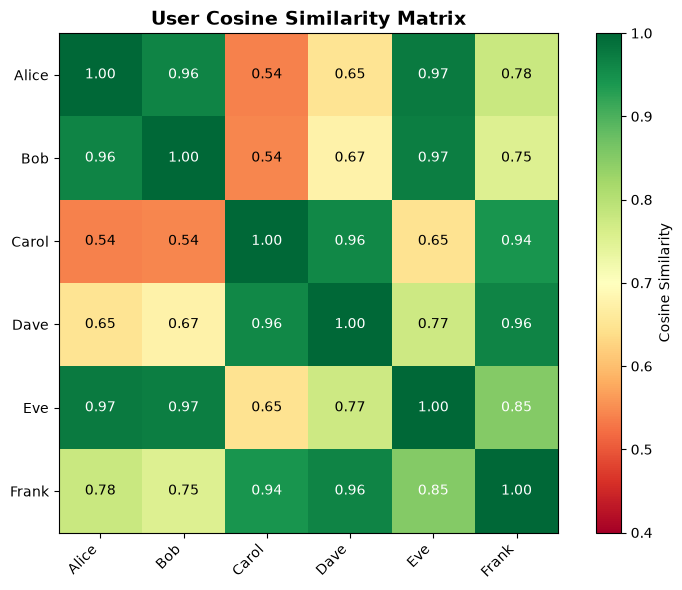

Notice: Alice-Bob-Eve cluster (action fans) and Carol-Dave-Frank cluster (romance fans)


In [26]:
# Compute all pairwise similarities
n = len(users)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = cosine_similarity(ratings[i], ratings[j])

# Heatmap visualization
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0.4, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(users, rotation=45, ha='right')
ax.set_yticklabels(users)
ax.set_title("User Cosine Similarity Matrix", fontsize=14, fontweight='bold')

for i in range(n):
    for j in range(n):
        color = 'white' if sim_matrix[i, j] > 0.8 else 'black'
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha='center', va='center',
                fontsize=10, color=color)

plt.colorbar(im, label='Cosine Similarity')
plt.tight_layout()
plt.show()

print("Notice: Alice-Bob-Eve cluster (action fans) and Carol-Dave-Frank cluster (romance fans)")

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 7: Mini-Project — Movie Recommendation Engine</h2>
</div>

Now we put it all together: build a recommendation engine using cosine similarity!

In [27]:
print("=" * 60)
print("MINI-PROJECT: Movie Recommendation Engine")
print("=" * 60)

# Step 1: Choose a target user
target_user = 'Eve'
target_idx = users.index(target_user)
print(f"\nTarget user: {target_user}")
print(f"Eve's ratings: {ratings[target_idx]}")
for j, movie in enumerate(movies):
    print(f"  {movie}: {ratings[target_idx, j]}")

# Step 2: Find most similar user
print(f"\n--- Finding Most Similar User ---")
similarities = {}
for i, user in enumerate(users):
    if i != target_idx:
        sim = cosine_similarity(ratings[target_idx], ratings[i])
        similarities[user] = sim
        print(f"  {target_user} vs {user}: {sim:.4f}")

most_similar = max(similarities, key=similarities.get)
print(f"\n→ Most similar to {target_user}: {most_similar} "
      f"(similarity = {similarities[most_similar]:.4f})")

# Step 3: Generate recommendations
print(f"\n--- Generating Recommendations ---")
similar_idx = users.index(most_similar)
recommendations = []
for j, movie in enumerate(movies):
    target_r = ratings[target_idx, j]
    similar_r = ratings[similar_idx, j]
    if similar_r >= 4 and target_r <= 2:
        recommendations.append((movie, similar_r))

print(f"\n{'=' * 60}")
print(f"RECOMMENDATIONS for {target_user}:")
if recommendations:
    for movie, rating in recommendations:
        print(f"  → Watch '{movie}' ({most_similar} rated it {rating}/5)")
else:
    print(f"  {target_user} and {most_similar} already agree on most movies!")
print(f"{'=' * 60}")
print(f"\nThis is collaborative filtering — the foundation of Netflix!")

MINI-PROJECT: Movie Recommendation Engine

Target user: Eve
Eve's ratings: [5 3 4 2 5]
  Inception: 5
  Titanic: 3
  Avengers: 4
  Notebook: 2
  Interstellar: 5

--- Finding Most Similar User ---
  Eve vs Alice: 0.9747
  Eve vs Bob: 0.9716
  Eve vs Carol: 0.6465
  Eve vs Dave: 0.7731
  Eve vs Frank: 0.8505

→ Most similar to Eve: Alice (similarity = 0.9747)

--- Generating Recommendations ---

RECOMMENDATIONS for Eve:
  Eve and Alice already agree on most movies!

This is collaborative filtering — the foundation of Netflix!


<div style="background: #EAFAF1; color: black; border-left: 5px solid #2ECC71; padding: 15px; margin: 15px 0;">
<strong>✅ Session Summary — Key Takeaways:</strong>
<ol>
<li>A <strong>vector</strong> is a NumPy array representing a data point</li>
<li>The <strong>dot product</strong> (<code>@</code>) measures alignment — the fundamental ML operation</li>
<li>A <strong>matrix</strong> organizes vectors into rows (samples) and columns (features)</li>
<li><strong>Matrix multiply:</strong> (m×n) @ (n×p) → (m×p). Inner dims must match.</li>
<li><code>*</code> ≠ <code>@</code> — element-wise is NOT matrix multiply</li>
<li><strong>Transpose</strong> (<code>.T</code>) swaps rows and columns</li>
<li>Every <strong>image</strong> is a 3D array: (height, width, channels)</li>
<li><strong>np.linalg</strong> provides norm, det, inv, solve</li>
<li><strong>Cosine similarity</strong> normalizes for magnitude — measures direction only</li>
<li><strong>Recommendation engines</strong> use cosine similarity to find similar users</li>
</ol>
</div>

## What's Next

**Session 6.2: Probability Fundamentals** — Today we answered "how similar are two things?" with cosine similarity. Next, we answer "how likely is something to happen?" with probability. You'll learn probability rules, conditional probability P(A|B), and Bayes' theorem.

---

<div style="text-align:center; color:#666; padding:20px;">
<em>Vishlesan i-Hub IIT Patna × Masai School</em>
</div>